# Day2 · 블록2 · NumPy 배열 연산 & Matplotlib 실습

> **강의자료**: `강의자료/02.02.Python-NumPy.md`

| Part | 주제 |
|------|------|
| Part 1 | NumPy — 왜 필요한가? |
| Part 2 | ndarray 구조 이해 |
| Part 3 | 자주 쓰이는 NumPy 연산 |
| Part 4 | 센서 데이터 처리 실습 |
| Part 5 | Matplotlib — 센서 데이터 시각화 |
| Part 6 | 퀴즈 & 복습 문제 |

로봇의 센서(LiDAR, IMU)가 생성하는 대량의 수치 데이터를 NumPy 배열로 효율적으로 처리하고,
Matplotlib으로 시각화하는 방법을 배웁니다.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1: NumPy — 왜 필요한가?

로봇은 **Sense-Think-Act** 루프를 끊임없이 반복하며,
센서가 생성하는 대량의 데이터를 매우 짧은 시간 안에 계산해야 합니다.

| 방식 | 특징 |
|------|------|
| Python 리스트 | 다양한 타입 허용, 메모리 오버헤드 크고 느림 |
| NumPy ndarray | C 수준으로 최적화된 N차원 배열, 벡터화 연산으로 빠름 |

### 1.1 Python 리스트 vs NumPy — LiDAR 데이터 처리 비교

In [5]:
# Python 리스트 방식 (느림): 360개 LiDAR 거리에 보정치 추가
distances_list = [float(i) * 0.01 + 0.5 for i in range(360)]  # 예시 데이터

corrected_list = []
for d in distances_list:
    corrected_list.append(d + 0.1)  # 하나씩 순차 계산

print(f"Python 리스트 방식 — 첫 3개: {corrected_list[:3]}")

Python 리스트 방식 — 첫 3개: [0.6, 0.61, 0.62]


In [6]:
# NumPy 방식 (빠름): 배열 전체에 한 번에 적용 (벡터화 연산)
distances_np = np.array(distances_list)
corrected_np = distances_np + 0.1   # 배열 전체에 한 번에 적용

print(f"NumPy 방식 — 첫 3개: {corrected_np[:3]}")
print(f"두 결과 동일 여부: {np.allclose(corrected_list, corrected_np)}")

NumPy 방식 — 첫 3개: [0.6  0.61 0.62]
두 결과 동일 여부: True


---
## Part 2: ndarray 구조 이해

NumPy의 핵심 객체 `ndarray`는 로봇의 물리적 상태를 숫자로 추상화합니다.

| 속성 | 의미 | 로봇 예시 |
|------|------|-----------|
| **Dimension (차원)** | 데이터가 뻗어 나가는 방향 | 1D: IMU 가속도 (x,y,z), 2D: LiDAR 스캔 세트 |
| **Shape (형태)** | 각 차원의 크기 | `(360,)` → 1도 단위 LiDAR 360개 |
| **Dtype (데이터 타입)** | 저장되는 수의 형식 | 좌표/속도 → `float64`, 엔코더 틱 → `int` |

### 2.1 ndarray 구조 확인 실습

In [7]:
# 1D 배열: IMU 가속도 데이터 [x, y, z] (m/s^2)
accel = np.array([0.02, -0.01, 9.81])
print("=== 1D 배열: IMU 가속도 ===")
print(f"값:    {accel}")
print(f"shape: {accel.shape}")   # (3,)
print(f"dtype: {accel.dtype}")   # float64
print(f"ndim:  {accel.ndim}")    # 1

=== 1D 배열: IMU 가속도 ===
값:    [ 0.02 -0.01  9.81]
shape: (3,)
dtype: float64
ndim:  1


In [8]:
# 2D 배열: LiDAR 360도 (x, y) 좌표
point_cloud = np.zeros((360, 2))
print("=== 2D 배열: LiDAR 포인트 클라우드 ===")
print(f"shape: {point_cloud.shape}")   # (360, 2)
print(f"ndim:  {point_cloud.ndim}")    # 2

=== 2D 배열: LiDAR 포인트 클라우드 ===
shape: (360, 2)
ndim:  2


---
## Part 3: 자주 쓰이는 NumPy 연산

### 3.1 ① 배열 생성 (Creation)

| 함수 | 설명 | 로봇 활용 |
|------|------|-----------|
| `np.zeros()` | 모든 값이 0 | 데이터 버퍼 초기화 |
| `np.ones()` | 모든 값이 1 | 보정 계수 초기화 |
| `np.linspace()` | 일정 간격 수열 | LiDAR 각도 배열 생성 |
| `np.random.uniform()` | 균일 분포 난수 | 센서 노이즈 시뮬레이션 |

In [9]:
# 0으로 초기화된 배열 (데이터 버퍼 사전 할당)
sensor_buffer = np.zeros(100)
print(f"sensor_buffer shape: {sensor_buffer.shape}, 첫 5개: {sensor_buffer[:5]}")

# LiDAR 각도 배열: 0도 ~ 360도(2π), 360개 포인트
angles = np.linspace(0, 2 * np.pi, 360)
print(f"angles shape: {angles.shape}, 첫 값: {angles[0]:.4f}, 마지막: {angles[-1]:.4f}")

# 시뮬레이션용 랜덤 거리 데이터 (0.5m ~ 5.0m)
distances = np.random.uniform(0.5, 5.0, 360)
print(f"distances shape: {distances.shape}, 최솟값: {distances.min():.2f}m")

sensor_buffer shape: (100,), 첫 5개: [0. 0. 0. 0. 0.]
angles shape: (360,), 첫 값: 0.0000, 마지막: 6.2832
distances shape: (360,), 최솟값: 0.50m


### 3.2 ② 슬라이싱과 인덱싱 (Slicing & Indexing)

로봇의 특정 영역에 있는 데이터만 골라낼 때 사용합니다.

- 기본 슬라이싱: `array[start:end]`
- 불리언 인덱싱: 조건을 만족하는 요소만 추출

In [10]:
# 기본 슬라이싱: LiDAR 전방 데이터 추출 (90° ~ 270°)
front_data = distances[90:270]
print(f"전방 LiDAR 데이터 수: {len(front_data)}")
print(f"전방 최근접 거리: {front_data.min():.2f}m")

전방 LiDAR 데이터 수: 180
전방 최근접 거리: 0.50m


In [11]:
# 불리언 인덱싱: 1.0m 미만의 장애물만 추출
lidar_data = np.array([2.5, 0.5, 1.8, 0.9, 3.0])
obstacles = lidar_data[lidar_data < 1.0]
print(f"원본 데이터: {lidar_data}")
print(f"1m 미만 장애물 거리: {obstacles}")  # [0.5 0.9]

원본 데이터: [2.5 0.5 1.8 0.9 3. ]
1m 미만 장애물 거리: [0.5 0.9]


### 3.3 ③ 브로드캐스팅 (Broadcasting)

서로 다른 형태의 배열 간 연산을 NumPy가 자동으로 처리합니다.

- 스칼라 브로드캐스팅: 배열의 모든 원소에 같은 연산 적용
- 벡터 브로드캐스팅: 형태가 맞는 배열끼리 원소별 연산

In [12]:
# 로봇 팔 3축 가속도 데이터
accel_data = np.array([0.02, -0.01, 9.81])          # shape: (3,)
calibration_offset = np.array([0.01, 0.01, 0.00])   # shape: (3,)

# 각 축에 자동으로 오프셋 적용 (벡터 브로드캐스팅)
calibrated_accel = accel_data - calibration_offset
print(f"원본 가속도:   {accel_data}")
print(f"보정 후 가속도: {calibrated_accel}")   # [0.01 -0.02  9.81]

원본 가속도:   [ 0.02 -0.01  9.81]
보정 후 가속도: [ 0.01 -0.02  9.81]


In [13]:
# 스칼라 브로드캐스팅: 모든 값에 동일한 연산 적용
scaled = accel_data * 100
print(f"100배 스케일: {scaled}")   # [  2.  -1. 981.]

100배 스케일: [  2.  -1. 981.]


In [14]:
# LiDAR 거리 데이터 전체에 보정치 적용 (스칼라 브로드캐스팅)
raw_distances = np.array([1.2, 0.8, 1.5, 2.1, 0.6])
offset = 0.05   # 5cm 오프셋 보정
corrected = raw_distances + offset
print(f"보정 전: {raw_distances}")
print(f"보정 후: {corrected}")

보정 전: [1.2 0.8 1.5 2.1 0.6]
보정 후: [1.25 0.85 1.55 2.15 0.65]


### 3.4 ④ 수학 연산 (Math Operations)

센서 데이터 분석에 필수적인 통계·벡터 연산:

| 함수 | 설명 | 로봇 활용 |
|------|------|-----------|
| `mean()`, `std()` | 평균, 표준편차 | 센서 노이즈 특성 분석 |
| `min()`, `max()` | 최솟값, 최댓값 | 충돌 방지(가장 가까운 장애물 탐색) |
| `np.argmin()`, `np.argmax()` | 최솟값·최댓값의 인덱스 | 장애물 방향(각도) 탐색 |
| `np.linalg.norm()` | 벡터의 크기(L2 Norm) | IMU 총 가속도 크기 계산 |

In [33]:
lidar_data = np.array([4.2, 3.5, 1.1, 2.8, 0.8])

# 통계 분석
print(f"평균 거리:      {np.mean(lidar_data):.2f}m")
print(f"표준편차:       {np.std(lidar_data):.2f}m")
print(f"최근접 장애물:  {np.min(lidar_data):.2f}m")
print(f"최원거리 장애물: {np.max(lidar_data):.2f}m")

# 가장 가까운 장애물의 방향(인덱스)
min_idx = np.argmin(lidar_data)
print(f"장애물 방향 인덱스: {min_idx}")   # 4

평균 거리:      2.48m
표준편차:       1.33m
최근접 장애물:  0.80m
최원거리 장애물: 4.20m
장애물 방향 인덱스: 4


In [34]:
# IMU 총 가속도 크기 (L2 Norm = sqrt(x^2 + y^2 + z^2))
accel = np.array([0.02, -0.01, 9.81])
total = np.linalg.norm(accel)
print(f"총 가속도: {total:.2f} m/s^2")    # ≈ 9.81

총 가속도: 9.81 m/s^2


---
## Part 4: 센서 데이터 처리 실습

### 4.1 LiDAR & IMU 통합 데이터 처리

In [17]:
# 1. LiDAR 데이터 처리: 각도 생성 및 거리 데이터 시뮬레이션
angles = np.linspace(0, 2 * np.pi, 360)          # 0~360도 각도
distances = np.random.uniform(0.5, 5.0, 360)     # 랜덤 거리 데이터

# 특정 각도 범위(전방 30도) 데이터 추출: 인덱스 165~195 (165°~195°)
front_data = distances[165:195]
if np.min(front_data) < 1.0:   # 가장 가까운 장애물이 1m 이내라면
    print("경고: 전방 장애물 감지! 정지 명령 수행")
else:
    print(f"전방 안전. 최근접 거리: {np.min(front_data):.2f}m")

경고: 전방 장애물 감지! 정지 명령 수행


In [18]:
# 2. IMU 가속도 데이터 처리
accel_data = np.array([0.02, -0.01, 9.81])         # [x, y, z] (m/s^2)
calibration_offset = np.array([0.01, 0.01, 0.00])

# 브로드캐스팅을 이용한 보정
calibrated_accel = accel_data - calibration_offset

# 총 가속도 크기(L2 Norm) 계산
total_accel = np.linalg.norm(calibrated_accel)
print(f"총 가속도: {total_accel:.2f} m/s^2")

총 가속도: 9.81 m/s^2


### 4.2 센서 노이즈 시뮬레이션

현실의 센서는 완벽하지 않으며 항상 노이즈를 포함합니다.
NumPy의 가우시안 분포로 노이즈를 쉽게 모사할 수 있습니다.

In [19]:
angles = np.linspace(0, 2 * np.pi, 360)
distances = np.random.uniform(0.5, 5.0, 360)

# 가우시안 노이즈 시뮬레이션 (표준편차 5cm 수준)
noise_level = 0.05
noise = np.random.normal(0, noise_level, distances.shape)

# 노이즈가 섞인 실제 센서 데이터 생성
noisy_lidar = distances + noise

# 필터링 전후 비교
print(f"원본 평균 거리:       {np.mean(distances):.2f}m")
print(f"노이즈 포함 평균 거리: {np.mean(noisy_lidar):.2f}m")
print(f"노이즈 표준편차:       {np.std(noisy_lidar - distances):.4f}m")

원본 평균 거리:       2.83m
노이즈 포함 평균 거리: 2.83m
노이즈 표준편차:       0.0486m


### 4.3 NumPy 입문자가 자주 하는 실수

| 실수 | 잘못된 방법 | 올바른 방법 |
|------|-------------|-------------|
| ① for 루프 사용 | `for d in arr: result.append(d + 1)` | `arr + 1` (벡터화) |
| ② Shape 불일치 | `(3,)` 배열과 `(3, 1)` 배열 연산 | `shape` 확인 후 연산 |
| ③ Dtype 무시 | 정수형 배열에 실수값 저장 | `float64` 타입 유지 |
| ④ 얕은 복사 | `b = a` (원본 공유) | `b = a.copy()` (독립 복사) |

In [20]:
# 실수 ④ 얕은 복사 vs 깊은 복사
a = np.array([1.0, 2.0, 3.0])
b = a           # 얕은 복사: a와 b가 같은 메모리 공유
c = a.copy()    # 깊은 복사: c는 독립적인 복사본

b[0] = 99.0
print(f"a = {a}")   # a[0]도 99.0으로 변경됨 (주의!)
print(f"b = {b}")
print(f"c = {c}")   # c는 원본 유지

a = [99.  2.  3.]
b = [99.  2.  3.]
c = [1. 2. 3.]


In [21]:
# 실수 ③ Dtype 무시 — 정수형 배열에 실수 저장 시 소수점 손실
int_arr = np.array([1, 2, 3], dtype=int)
int_arr[0] = 1.9     # 소수점 버림 발생
print(f"정수형 배열 저장: {int_arr[0]} (1.9 → 1로 잘림)")

float_arr = np.array([1.0, 2.0, 3.0], dtype=float)
float_arr[0] = 1.9   # 소수점 유지
print(f"실수형 배열 저장: {float_arr[0]} (정상)")

정수형 배열 저장: 1 (1.9 → 1로 잘림)
실수형 배열 저장: 1.9 (정상)


---
## Part 5: Matplotlib — 센서 데이터 시각화

### 5.1 Matplotlib의 구조

Matplotlib은 세 가지 계층으로 구성됩니다.

| 계층 | 설명 |
|------|------|
| **Figure (캔버스)** | 그래프가 그려지는 가장 바깥 창, 하나 이상의 Axes를 포함 |
| **Axes (좌표계/플롯)** | 실제 데이터가 그려지는 구역, '그래프 하나'에 해당 |
| **Artist (구성요소)** | Figure에 보이는 모든 것 (선, 텍스트, 점, 범례 등) |

### 5.2 로봇 개발에서 자주 쓰이는 그래프 유형

| 유형 | 로봇 활용 |
|------|-----------|
| **시계열 라인 그래프** | IMU/엔코더 피드백, PID 오차 신호 시각화, 배터리 전압 변화 |
| **LiDAR 산점도** | 2D 공간 장애물 탐지 및 경계 시각화 |
| **히스토그램** | 센서 노이즈 분포 분석, 필터 알고리즘 설계 기초 |

### 5.3 센서 데이터 시각화 예제 — LiDAR 산점도 + IMU 시계열

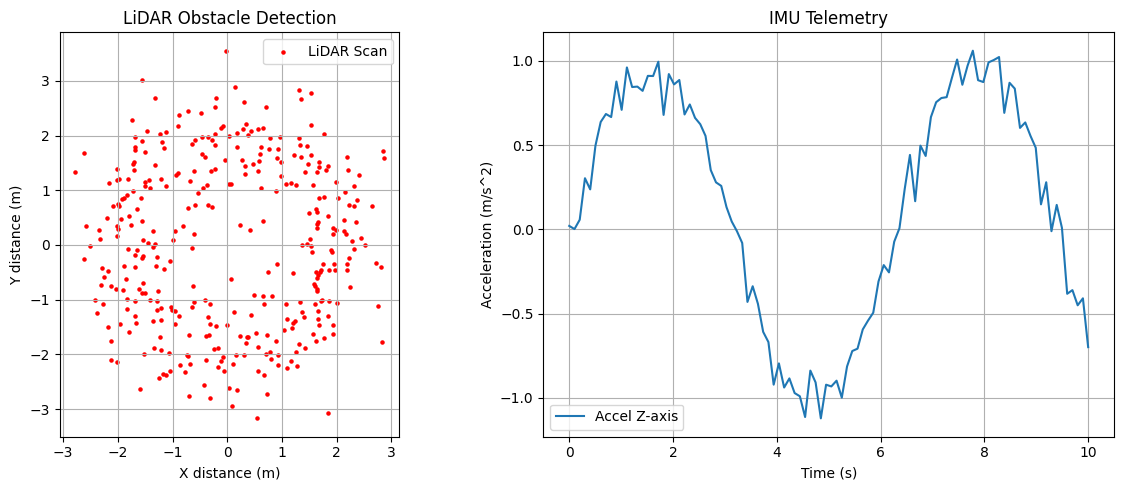

In [22]:
# 시뮬레이션 데이터 생성
angles = np.linspace(0, 2 * np.pi, 360)
distances = 2 + 0.5 * np.random.randn(360)   # 노이즈 포함 LiDAR
x = distances * np.cos(angles)               # 극좌표 → 직교좌표
y = distances * np.sin(angles)

time = np.linspace(0, 10, 100)
imu_accel = np.sin(time) + 0.1 * np.random.randn(100)

# subplot으로 여러 데이터를 한 화면에 표시
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x, y, s=5, c='red', label='LiDAR Scan')
ax1.set_title("LiDAR Obstacle Detection")
ax1.set_xlabel("X distance (m)")
ax1.set_ylabel("Y distance (m)")
ax1.grid(True)
ax1.legend()
ax1.set_aspect('equal')

ax2.plot(time, imu_accel, label='Accel Z-axis')
ax2.set_title("IMU Telemetry")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Acceleration (m/s^2)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("sensor_diagnostic.png")
plt.show()

### 5.4 그래프 꾸미기 및 관리

- **범례(Legend)**: 여러 센서 데이터를 동시에 그릴 때 각 선의 의미 구분에 필수
- **그리드(Grid)**: 장애물까지의 거리를 직관적으로 가늠
- **파일 저장 (`plt.savefig()`)**: PNG/PDF로 저장하여 보고서 작성·사후 분석에 활용

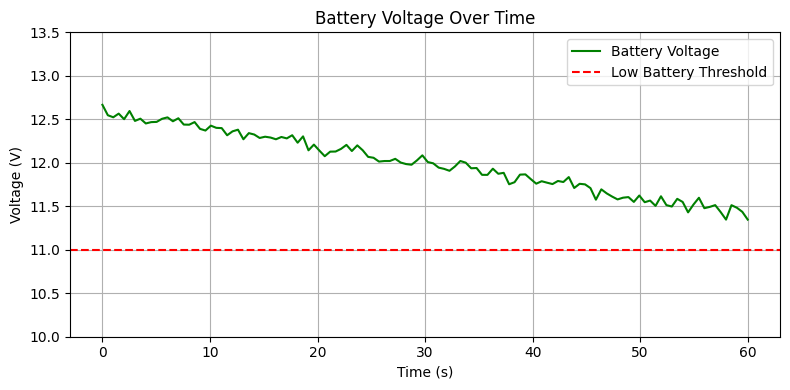

In [23]:
# 배터리 전압 시계열 시각화 예시
time_s = np.linspace(0, 60, 120)                            # 60초간 0.5초 간격
battery_voltage = 12.6 - 0.02 * time_s + 0.05 * np.random.randn(120)  # 방전 시뮬레이션

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_s, battery_voltage, color='green', label='Battery Voltage')
ax.axhline(y=11.0, color='red', linestyle='--', label='Low Battery Threshold')
ax.set_title("Battery Voltage Over Time")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_ylim(10.0, 13.5)   # 고정된 시야 확보
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("battery_monitor.png")
plt.show()

### 5.5 Matplotlib 입문자가 자주 하는 실수

| 실수 | 문제 | 해결책 |
|------|------|--------|
| ① NumPy 미사용 | 리스트로 플로팅 → 느림 | NumPy 벡터화 연산 후 플로팅 |
| ② 루프 내 Figure 생성 | `while`안에서 `plt.figure()` 반복 → 메모리 부족 | 루프 밖에서 한 번만 생성 |
| ③ 축 범위 미설정 | 로봇 이동에 따라 축 자동 변경 | `ax.set_xlim()`, `ax.set_ylim()` 고정 |
| ④ 차단형 플로팅 | `plt.show()`가 프로그램을 멈춤 | 제어 루프와 병행 시 `plt.ion()` 활용 |

---
## Part 6: 퀴즈 & 복습 문제

### 6.1 코드 읽기 — NumPy 출력 예측

아래 코드의 출력 결과를 예측해 보세요.

In [24]:
# Q1. 초음파 센서 거리 보정
distances = np.array([1.2, 0.8, 1.5])

In [25]:
# Q2. 안전 거리 필터링
lidar_data = np.array([2.5, 0.5, 1.8, 0.9, 3.0])

In [26]:
# Q3. 배터리 전압 평균
voltages = np.array([12.6, 12.4, 12.5])

In [27]:
# Q4. 가장 가까운 장애물 인덱스
scans = np.array([4.2, 3.5, 1.1, 2.8])

In [28]:
# Q5. 배열 형태 확인
point_cloud = np.zeros((360, 2))

### 6.2 TODO 실습 — LiDAR 안전 판단 함수 구현

아래 함수를 완성하세요.
- 요구사항: LiDAR 거리 배열을 받아 전방 위험 여부를 판단하는 함수 작성
- `front_sector` 슬라이싱으로 전방 데이터 추출 후 최근접 거리 반환
- 최근접 거리가 `threshold`보다 작으면 `True` 반환
- Hint: `np.min()`, 불리언 반환

In [36]:
def is_obstacle_ahead(_distances: np.ndarray, _threshold: float = 1.0) -> bool:
    # TODO: 여기에 구현하세요
    # 1. distances[165:195] 로 전방 30도 데이터 추출
    # 2. 그 중 최솟값을 계산
    # 3. 최솟값이 threshold 미만이면 True 반환
    ...

# 완성 후 주석 해제하여 테스트
# test_distances = np.random.uniform(0.5, 5.0, 360)
# test_distances[180] = 0.5   # 전방 정면에 장애물 배치
# result = is_obstacle_ahead(test_distances, threshold=1.0)
# print(f"전방 장애물 감지: {result}")   # True 기대

In [38]:
def is_obstacle_ahead(_distances: np.ndarray, _threshold: float = 1.0) -> bool:
    foward = _distances[165:195]
    min_distance = np.min(foward)
    if min_distance < _threshold:
        return True
    else:
        return False


test_distances = np.random.uniform(0.5, 5.0, 360)
test_distances[180] = 0.5   # 전방 정면에 장애물 배치
result = is_obstacle_ahead(test_distances, _threshold=1.0)
print(f"전방 장애물 감지: {result}")   # True 기대

전방 장애물 감지: True


### 6.3 TODO 실습 — 극좌표 → 직교좌표 변환 및 시각화

아래 코드를 완성하세요.
- 요구사항: LiDAR의 각도·거리 데이터를 (x, y) 좌표로 변환하고 산점도로 시각화
- Hint: `x = r * np.cos(θ)`, `y = r * np.sin(θ)`

In [ ]:
# TODO: 여기에 구현하세요
# 1. np.linspace로 0 ~ 2π 구간의 360개 각도 배열 생성
# 2. np.random.uniform으로 0.5 ~ 5.0 범위의 360개 거리 배열 생성
# 3. x, y 좌표 계산 (극좌표 → 직교좌표)
# 4. plt.scatter로 산점도 그리기
# 5. 제목, 축 레이블, 그리드 설정 후 plt.show()

# angles = ...
# distances = ...
# x = ...
# y = ...

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.scatter(x, y, s=5, c='blue')
# ax.set_title("LiDAR Point Cloud")
# ax.set_xlabel("X (m)")
# ax.set_ylabel("Y (m)")
# ax.set_aspect('equal')
# ax.grid(True)
# plt.tight_layout()
# plt.show()

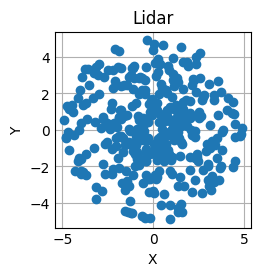

In [ ]:
angles = np.linspace(0, np.pi * 2, 360)
distances = np.random.uniform(0.5, 5.0, 360)
x = distances * np.cos(angles)
y = distances * np.sin(angles)

plt.scatter(x, y)
plt.title("Lidar")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()